# Objective 1

### Identify Substitute Products for a Focus Product

Load the required files as dataframes.

In [19]:
import pandas as pd
%run ../utils/calculations.py
%run ../utils/objective-1.py

file_path_root = "../data/results/obj1/substitutes"

# Convert CSV files into dataframes
sampled_df = pd.read_csv('../data/results/sample-pairwise.csv')
product_df = pd.read_csv('../data/cleaned/product-info.csv')
sampled_products = pd.read_csv('../data/results/sampled-products.csv')

Iteration 1 (defaults)

Substitution index: 0.5
Jaccard: 0.3
Conditional: 0.2
Similarity weight: same as current (1.0, 0.7, 0.4)

In [22]:
%run ../utils/objective-1.py

file_path_root = "../data/results/obj1/substitutes"
# Run first version of score calculation, use default weights
version_num = 1
file_path = f"{file_path_root}-{version_num}.csv"
compute_hybrid_substitution_score(
    product_df,
    sampled_df,
    sampled_products['product_id'].tolist(),
    file_path)

Completed substitute calculations. Saved to ../data/results/obj1/substitutes-1.csv


In [25]:
%run ../utils/objective-1.py

substitutes_df = pd.read_csv(file_path)
eval_file_path = f"{file_path_root}-results-{version_num}.csv"
get_substitutes_and_evaluate(product_df, sampled_df, substitutes_df, eval_file_path)

 Best threshold determined as: 0.472

***Substitution Validation Summary***

Average fraction of substitutes in same department: 0.993
Average fraction of substitutes in same aisle: 1.000
Average substitution score: 0.576
Average number of substitutes per product: 21.3
Fraction of valid/possible substitutes not identified: 0.090

Co-occurrence correlations:
 - Score vs joint frequency (P_ij): 0.620
 - Score vs lift: 0.058

Feature correlations:
                    substitution_index   jaccard  conditional
substitution_index            1.000000 -0.645028    -0.709815
jaccard                      -0.645028  1.000000     0.540210
conditional                  -0.709815  0.540210     1.000000


Iteration 2

Substitution index: 0.6
Jaccard: 0.2
Conditional: 0.2
Similarity weight: (1.0, 0.8, 0.5)

In [26]:
%run ../utils/objective-1.py

file_path_root = "../data/results/obj1/substitutes"
# Run first version of score calculation, use default weights
version_num = 2
file_path = f"{file_path_root}-{version_num}.csv"
compute_hybrid_substitution_score(
    product_df,
    sampled_df,
    sampled_products['product_id'].tolist(),
    file_path,
    0.6, 0.2, 0.2, 0.8, 0.5)

Completed substitute calculations. Saved to ../data/results/obj1/substitutes-2.csv


In [27]:
%run ../utils/objective-1.py

substitutes_df = pd.read_csv(file_path)
eval_file_path = f"{file_path_root}-results-{version_num}.csv"
get_substitutes_and_evaluate(product_df, sampled_df, substitutes_df, eval_file_path)

 Best threshold determined as: 0.480

***Substitution Validation Summary***

Average fraction of substitutes in same department: 1.000
Average fraction of substitutes in same aisle: 1.000
Average substitution score: 0.569
Average number of substitutes per product: 18.8
Fraction of valid/possible substitutes not identified: 0.219

Co-occurrence correlations:
 - Score vs joint frequency (P_ij): 0.108
 - Score vs lift: -0.282

Feature correlations:
                    substitution_index   jaccard  conditional
substitution_index            1.000000 -0.516885    -0.069956
jaccard                      -0.516885  1.000000     0.148746
conditional                  -0.069956  0.148746     1.000000


Iteration 3

Substitution index: 0.65
Jaccard: 0.2
Conditional: 0.15
Similarity weight: (1.0, 0.7, 0.4)

In [28]:
%run ../utils/objective-1.py

file_path_root = "../data/results/obj1/substitutes"
# Run first version of score calculation, use default weights
version_num = 3
file_path = f"{file_path_root}-{version_num}.csv"
compute_hybrid_substitution_score(
    product_df,
    sampled_df,
    sampled_products['product_id'].tolist(),
    file_path,
    0.65, 0.2, 0.15, 0.7, 0.4)

Completed substitute calculations. Saved to ../data/results/obj1/substitutes-3.csv


In [29]:
%run ../utils/objective-1.py

substitutes_df = pd.read_csv(file_path)
eval_file_path = f"{file_path_root}-results-{version_num}.csv"
get_substitutes_and_evaluate(product_df, sampled_df, substitutes_df, eval_file_path)

 Best threshold determined as: 0.458 and adjusted to: 0.467314576681927

***Substitution Validation Summary***

Average fraction of substitutes in same department: 1.000
Average fraction of substitutes in same aisle: 1.000
Average substitution score: 0.613
Average number of substitutes per product: 20.0
Fraction of valid/possible substitutes not identified: 0.157

Co-occurrence correlations:
 - Score vs joint frequency (P_ij): 0.111
 - Score vs lift: -0.292

Feature correlations:
                    substitution_index   jaccard  conditional
substitution_index            1.000000 -0.626366    -0.193029
jaccard                      -0.626366  1.000000     0.213326
conditional                  -0.193029  0.213326     1.000000


Iteration 4
Threshold adjustment

In [31]:
%run ../utils/objective-1.py

substitutes_df = pd.read_csv(file_path)
eval_file_path = f"{file_path_root}-results-4.csv"
get_substitutes_and_evaluate(product_df, sampled_df, substitutes_df, eval_file_path)

 Best threshold determined as: 0.458 and adjusted to: 0.4717361699334994

***Substitution Validation Summary***

Average fraction of substitutes in same department: 1.000
Average fraction of substitutes in same aisle: 1.000
Average substitution score: 0.613
Average number of substitutes per product: 20.0
Fraction of valid/possible substitutes not identified: 0.160

Co-occurrence correlations:
 - Score vs joint frequency (P_ij): 0.113
 - Score vs lift: -0.295

Feature correlations:
                    substitution_index   jaccard  conditional
substitution_index            1.000000 -0.618809    -0.182225
jaccard                      -0.618809  1.000000     0.206029
conditional                  -0.182225  0.206029     1.000000


### Results Analysis

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score


# Load the final substitutes dataframe
substitutes_df = pd.read_csv('../data/results/obj1/substitutes-4-full.csv')
products_df = pd.read_csv('../dataset/products.csv')

#print("\n=== Joining Department and Aisle Info ===")

# Join to add product info
substitutes_df = substitutes_df.merge(
    products_df[['product_id', 'department_id', 'aisle_id']],
    on='product_id',
    how='left'
).rename(columns={'department_id': 'product_dept', 'aisle_id': 'product_aisle'})

# Join to add substitute info
substitutes_df = substitutes_df.merge(
    products_df[['product_id', 'department_id', 'aisle_id']],
    left_on='substitute_id',
    right_on='product_id',
    how='left',
    suffixes=('', '_sub')
).rename(columns={'department_id': 'substitute_dept', 'aisle_id': 'substitute_aisle'})

# Drop redundant column created by merge
substitutes_df = substitutes_df.drop(columns=['product_id_sub'], errors='ignore')


# --- BASIC DISTRIBUTION ---
print("\n=== Overall Distribution of Substitution Scores ===")
summary_stats = substitutes_df['score'].describe().to_frame().T
print(summary_stats)

# Bin distribution
bins = np.linspace(substitutes_df['score'].min(), substitutes_df['score'].max(), 11)
bin_counts = pd.cut(substitutes_df['score'], bins).value_counts().sort_index()
print("\nScore Distribution by Bin:")
print(bin_counts)

# --- DEPARTMENT LEVEL ANALYSIS ---
print("\n=== Average Substitution Score per Department ===")
dept_avg = substitutes_df.groupby('product_dept')['score'].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False)
print(dept_avg.head(15))

# Count identified substitutes per department
if 'identified_substitute' in substitutes_df.columns:
    identified_counts = substitutes_df[substitutes_df['identified_substitute'] == True].groupby('product_dept').size()
    print("\nIdentified Substitutes per Department:")
    print(identified_counts.sort_values(ascending=False).head(15))

# --- CROSS-DEPARTMENT SUBSTITUTIONS ---
print("\n=== Cross- vs Within-Department Substitutions ===")
substitutes_df['same_department'] = substitutes_df['product_dept'] == substitutes_df['substitute_dept']
cross_stats = substitutes_df.groupby('same_department')['score'].agg(['mean', 'count'])
cross_stats.index = cross_stats.index.map({True: 'Within Department', False: 'Across Departments'})
print(cross_stats)

# --- SIMILARITY WEIGHT IMPACT ---
if 'similarity_weight' in substitutes_df.columns:
    print("\n=== Average Score by Similarity Weight ===")
    sim_weight_stats = substitutes_df.groupby('similarity_weight')['score'].agg(['mean', 'median', 'count'])
    print(sim_weight_stats.sort_index(ascending=False))

# --- VALIDATION METRICS ---
if 'identified_substitute' in substitutes_df.columns:
    print("\n=== Validation Metrics (Based on Identified Substitutes) ===")
    preds = substitutes_df['score'] >= threshold

    precision = precision_score(substitutes_df['identified_substitute'], preds, zero_division=0)
    recall = recall_score(substitutes_df['identified_substitute'], preds, zero_division=0)
    f1 = f1_score(substitutes_df['identified_substitute'], preds, zero_division=0)
    acc = accuracy_score(substitutes_df['identified_substitute'], preds)

    print(f"Precision: {precision:.3f}")
    print(f"Recall:    {recall:.3f}")
    print(f"F1 Score:  {f1:.3f}")
    print(f"Accuracy:  {acc:.3f}")

# --- TOP SUBSTITUTES PER DEPARTMENT ---
print("\n=== Top Substitutes per Department (Example) ===")
top_subs = (
    substitutes_df
    .sort_values('score', ascending=False)
    .groupby('product_dept')
    .head(3)[['product_dept', 'product_id', 'substitute_id', 'score']]
)
print(top_subs.head(20))



=== Overall Distribution of Substitution Scores ===
          count      mean       std       min       25%       50%       75%  \
score  119448.0  0.581484  0.088432  0.092314  0.550492  0.622763  0.643328   

        max  
score  0.65  

Score Distribution by Bin:
score
(0.0923, 0.148]       63
(0.148, 0.204]       105
(0.204, 0.26]        395
(0.26, 0.315]       2076
(0.315, 0.371]      1046
(0.371, 0.427]      2166
(0.427, 0.483]     15278
(0.483, 0.538]      6831
(0.538, 0.594]     14259
(0.594, 0.65]      77227
Name: count, dtype: int64

=== Average Substitution Score per Department ===
                  mean    median  count
product_dept                           
1             0.599557  0.638088  12455
19            0.599239  0.637821  16136
15            0.595817  0.633656   5229
4             0.594855  0.613525   5671
9             0.594830  0.629643   4550
17            0.592968  0.623990   6204
13            0.592557  0.623867  11782
5             0.589877  0.614282   1595

Substitution Score Summary:
 count    119448.000000
mean          0.581484
std           0.088432
min           0.092314
25%           0.550492
50%           0.622763
75%           0.643328
max           0.650000
Name: score, dtype: float64


C:\Users\jenle\AppData\Local\Temp\ipykernel_21368\607554227.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dept_summary.sort_values('avg_score', ascending=False), x='product_dept', y='avg_score', palette='viridis')


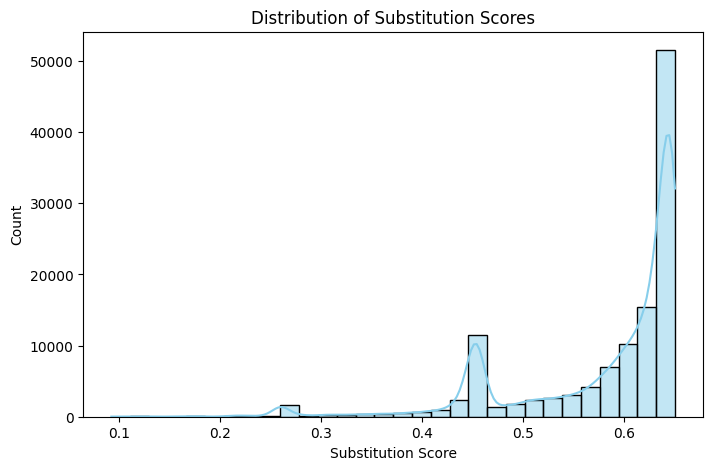

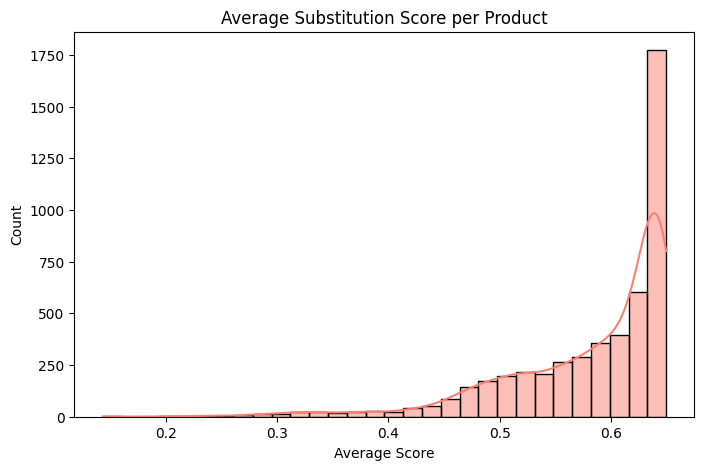

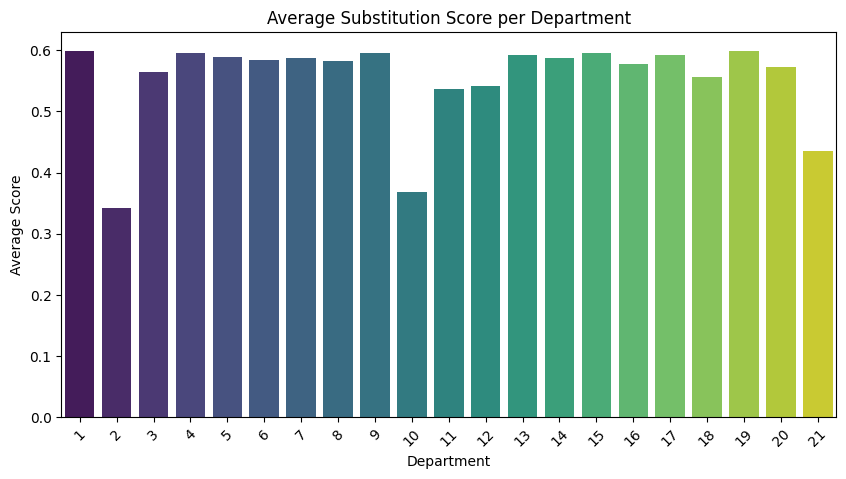

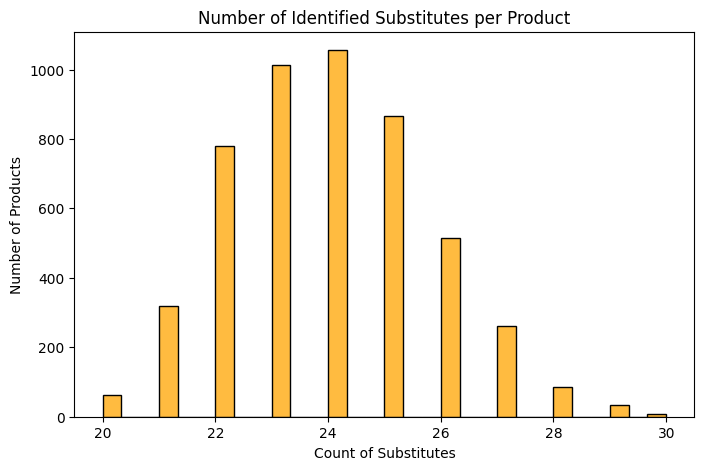

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the final substitutes dataframe
substitutes_df = pd.read_csv('../data/results/obj1/substitutes-4-full.csv')
products_df = pd.read_csv('../dataset/products.csv')

#print("\n=== Joining Department and Aisle Info ===")

# Join to add product info
substitutes_df = substitutes_df.merge(
    products_df[['product_id', 'department_id', 'aisle_id']],
    on='product_id',
    how='left'
).rename(columns={'department_id': 'product_dept', 'aisle_id': 'product_aisle'})

# Join to add substitute info
substitutes_df = substitutes_df.merge(
    products_df[['product_id', 'department_id', 'aisle_id']],
    left_on='substitute_id',
    right_on='product_id',
    how='left',
    suffixes=('', '_sub')
).rename(columns={'department_id': 'substitute_dept', 'aisle_id': 'substitute_aisle'})

# Drop redundant column created by merge
substitutes_df = substitutes_df.drop(columns=['product_id_sub'], errors='ignore')

# -----------------------------
# 1. Substitution Score Distribution
# -----------------------------
plt.figure(figsize=(8,5))
sns.histplot(substitutes_df['score'], bins=30, kde=True, color='skyblue')
plt.title("Distribution of Substitution Scores")
plt.xlabel("Substitution Score")
plt.ylabel("Count")
plt.savefig(f"dist-sub-scores.png") 

# Summary stats
score_summary = substitutes_df['score'].describe()
print("Substitution Score Summary:\n", score_summary)

# -----------------------------
# 2. Average Substitution Score per Product
# -----------------------------
product_scores = substitutes_df.groupby('product_id')['score'].mean().reset_index(name='avg_score')
plt.figure(figsize=(8,5))
sns.histplot(product_scores['avg_score'], bins=30, kde=True, color='salmon')
plt.title("Average Substitution Score per Product")
plt.xlabel("Average Score")
plt.ylabel("Count")
plt.savefig(f"avg_sub_score_per_product.png") 

# -----------------------------
# 3. Average Substitution Score per Department
# -----------------------------
dept_scores = substitutes_df.groupby('product_dept')['score'].mean().reset_index(name='avg_score')
dept_counts = substitutes_df.groupby('product_dept')['substitute_id'].count().reset_index(name='num_substitutes')
dept_summary = dept_scores.merge(dept_counts, on='product_dept')

plt.figure(figsize=(10,5))
sns.barplot(data=dept_summary.sort_values('avg_score', ascending=False), x='product_dept', y='avg_score', palette='viridis')
plt.xticks(rotation=45)
plt.title("Average Substitution Score per Department")
plt.ylabel("Average Score")
plt.xlabel("Department")
plt.savefig(f"avg_sub_score_per_dept.png") 

# -----------------------------
# 4. Substitution Counts per Product
# -----------------------------
subs_count_per_product = substitutes_df.groupby('product_id')['substitute_id'].count().reset_index(name='num_substitutes')
plt.figure(figsize=(8,5))
sns.histplot(subs_count_per_product['num_substitutes'], bins=30, color='orange')
plt.title("Number of Identified Substitutes per Product")
plt.xlabel("Count of Substitutes")
plt.ylabel("Number of Products")
plt.savefig(f"sub_count_per_product.png") 

